# 04. Quantum Classifier

Train a four-qubit variational classifier on the same features and held-out period used in
notebook 03. The readout averages PauliZ on wires 0 and 1. Their combined causal cones cover all
four inputs without measuring every wire. Training uses backpropagation on PennyLane's state-vector
simulator and a reproducible 300-row stratified sample from the training period.

In [1]:
import sys
sys.path.insert(0, '..')

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

from src.features import FEATURE_COLUMNS
from src.quantum_model import make_circuit, train_vqc, predict_vqc, RANDOM_STATE

## Load features, select the 4 SHAP-ranked columns

In [2]:
features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)

selected_features = FEATURE_COLUMNS
X = features[selected_features]
y = features['stress']

split_idx = int(len(features) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1401, 4), Test: (467, 4)


## Normalize to [0, pi] for angle encoding

StandardScaler is fit on the training set only, then MinMaxScaler maps the standardized values
into the `[0, pi]` range that `qml.AngleEmbedding` expects.

In [3]:
std_scaler = StandardScaler().fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

angle_scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(X_train_std)
X_train_angle = angle_scaler.transform(X_train_std)
X_test_angle = angle_scaler.transform(X_test_std)

print(f"Train angle range: [{X_train_angle.min():.3f}, {X_train_angle.max():.3f}]")
print(f"Test angle range:  [{X_test_angle.min():.3f}, {X_test_angle.max():.3f}]")

Train angle range: [0.000, 3.142]
Test angle range:  [0.034, 2.192]


## Encode labels as -1 / 1

In [4]:
y_train_pm = np.where(y_train.values == 1, 1, -1)
y_test_pm = np.where(y_test.values == 1, 1, -1)

print(f"Train label counts: {dict(zip(*np.unique(y_train_pm, return_counts=True)))}")
print(f"Test label counts:  {dict(zip(*np.unique(y_test_pm, return_counts=True)))}")

Train label counts: {np.int64(-1): np.int64(1113), np.int64(1): np.int64(288)}
Test label counts:  {np.int64(-1): np.int64(439), np.int64(1): np.int64(28)}


## Stratified subsample for training

300 rows, stress ratio close to the full training set.

In [5]:
N_TRAIN_SUB = 300

rng = np.random.default_rng(RANDOM_STATE)
stress_idx = np.where(y_train_pm == 1)[0]
normal_idx = np.where(y_train_pm == -1)[0]

stress_frac = len(stress_idx) / len(y_train_pm)
n_stress_sub = int(round(N_TRAIN_SUB * stress_frac))
n_normal_sub = N_TRAIN_SUB - n_stress_sub

sub_idx = np.concatenate([
    rng.choice(stress_idx, size=n_stress_sub, replace=False),
    rng.choice(normal_idx, size=n_normal_sub, replace=False),
])
rng.shuffle(sub_idx)

X_train_sub = X_train_angle[sub_idx]
y_train_sub = y_train_pm[sub_idx]

print(f"Subsample size: {len(sub_idx)}")
print(f"Subsample stress rate: {(y_train_sub == 1).mean():.3f}")
print(f"Full training stress rate: {(y_train_pm == 1).mean():.3f}")

Subsample size: 300
Subsample stress rate: 0.207
Full training stress rate: 0.206


## Train the VQC

4 qubits, one per feature, angle-encoded.

In [6]:
N_QUBITS = 4
circuit = make_circuit(n_qubits=N_QUBITS)

started = time.perf_counter()
weights, loss_history = train_vqc(circuit, X_train_sub, y_train_sub, n_qubits=N_QUBITS)
training_seconds = time.perf_counter() - started
np.save('../data/processed/vqc_weights.npy', np.asarray(weights, dtype=float))

print(f"final loss: {loss_history[-1]:.4f}")
print(f"training time: {training_seconds:.1f} seconds")
print("Saved data/processed/vqc_weights.npy")

step 0, loss 0.8050


step 10, loss 0.6443


step 20, loss 0.5733


step 30, loss 0.5373


step 40, loss 0.5158


step 50, loss 0.5007


final loss: 0.4901
training time: 852.4 seconds
Saved data/processed/vqc_weights.npy


## Training loss curve

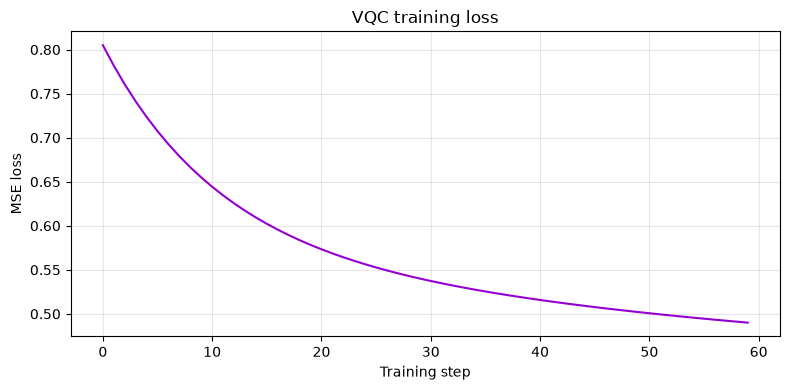

Saved figure: figures/04_vqc_loss.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='darkviolet')
ax.set_xlabel('Training step')
ax.set_ylabel('MSE loss')
ax.set_title('VQC training loss')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('../figures/04_vqc_loss.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/04_vqc_loss.png")

## Predict on the full test set

In [8]:
test_preds, test_raw = predict_vqc(circuit, X_test_angle, weights)

y_test_values = y_test.to_numpy(dtype=int)
test_scores = (test_raw + 1) / 2
tn, fp, fn, tp = confusion_matrix(y_test_values, test_preds, labels=[0, 1]).ravel()

quantum_results = {
    "model": "quantum_vqc_4_qubits",
    "auc": roc_auc_score(y_test_values, test_scores),
    "pr_auc": average_precision_score(y_test_values, test_scores),
    "brier": brier_score_loss(y_test_values, test_scores),
    "precision": precision_score(y_test_values, test_preds, zero_division=0),
    "recall": recall_score(y_test_values, test_preds, zero_division=0),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
}

pd.Series(quantum_results)

model        quantum_vqc_4_qubits
auc                      0.926294
pr_auc                    0.85628
brier                    0.048359
precision                     0.0
recall                        0.0
tn                            439
fp                              0
fn                             28
tp                              0
dtype: object

## Classical vs quantum comparison

In [9]:
classical_results = pd.read_csv('../data/processed/classical_results.csv')
comparison = pd.concat(
    [classical_results, pd.DataFrame([quantum_results])],
    ignore_index=True,
)
comparison.to_csv('../data/processed/model_results.csv', index=False)

comparison[[
    "model", "auc", "pr_auc", "brier", "precision", "recall",
    "tn", "fp", "fn", "tp",
]]

,model,auc,pr_auc,brier,precision,recall,tn,fp,fn,tp
0,lagged_volatility_logistic,0.997641,0.976077,0.018398,1.00,0.821429,439,0,5,23
1,gradient_boosting,0.994549,0.957384,0.011317,0.96,0.857143,438,1,4,24
2,quantum_vqc_4_qubits,0.926294,0.856280,0.048359,0.00,0.000000,439,0,28,0


**Interpretation**: the VQC ranks stress days above normal days reasonably well (AUC 0.926,
PR-AUC 0.856), but its probability scale is weak (Brier 0.048). At the fixed 0.5 threshold it
predicts no stress days, so precision and recall are both zero. The threshold was not tuned on the
test set. This is a negative result: the VQC does not beat the one-feature baseline or gradient
boosting, and its calibration would need separate validation before operational use. Training the
300-row sample for 60 steps took 852 seconds on the audit machine.